### 决策回归树案例【线性回归对比】

#### 创建数据可视化

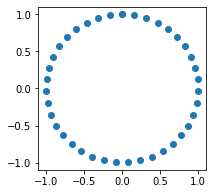

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import graphviz

X = np.linspace(0,2*np.pi,40).reshape(-1,1) # 数据，特征，训练数据
X_test = np.linspace(0,2*np.pi,199).reshape(-1,1) # 待测试数据，差异

# y 一个正弦波，余弦波，圆
y = np.c_[np.sin(X),np.cos(X)] # 正弦和余弦

# 画图--->圆
plt.figure(figsize=(3,3))
plt.scatter(y[:,0],y[:,1])

#### 线性回归建模

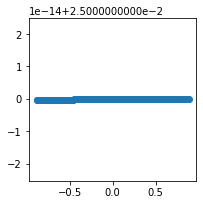

In [7]:
linear = LinearRegression()
linear.fit(X,y) #将数据交给算法，学习，希望算法，找到规律
# X ----> y 是一个圆；预测X_test返回值y_ 如果预测好，也是圆
y_ = linear.predict(X_test)
plt.figure(figsize=(3,3))
plt.scatter(y_[:,0],y_[:,1])

#### 决策树回归

(199, 2)


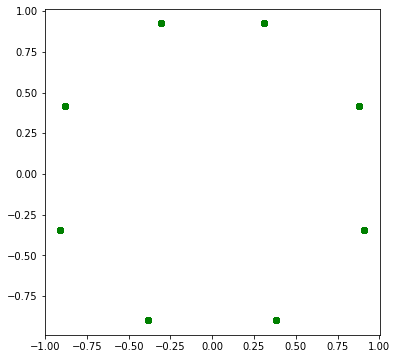

In [8]:
model = DecisionTreeRegressor(criterion='squared_error',max_depth=3)
model.fit(X,y)#X 是40个点 y是一个圆

y_ = model.predict(X_test) #X_test是199点【样本】，预测y_应该是一个圆

# 请问y_中有多少数据？？？
print(y_.shape)

plt.figure(figsize=(6,6))
plt.scatter(y_[:,0],y_[:,1],color = 'green')

#### 增加深度

(199, 2)


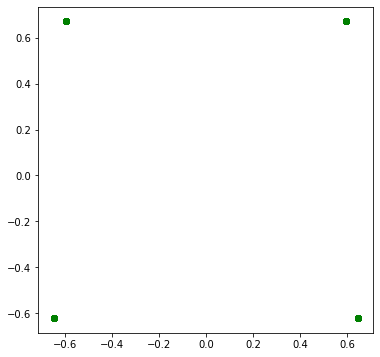

In [17]:
model = DecisionTreeRegressor(criterion='squared_error',max_depth=2)
model.fit(X,y)#X 是40个点 y是一个圆

y_ = model.predict(X_test) #X_test是199点【样本】，预测y_应该是一个圆

# 请问y_中有多少数据？？？
print(y_.shape)

plt.figure(figsize=(6,6))
plt.scatter(y_[:,0],y_[:,1],color = 'green')

#### 决策树可视化

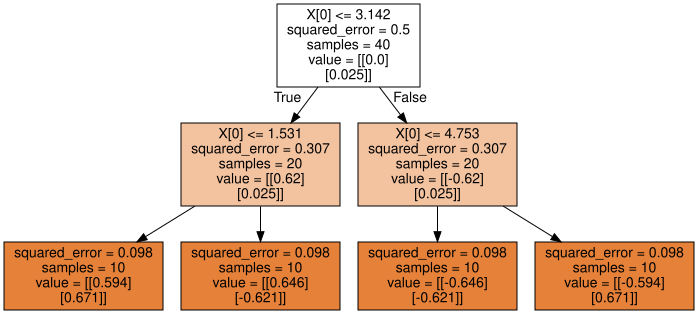

In [18]:
# 决策树形状
dot_data = tree.export_graphviz(model,filled=True)
graph = graphviz.Source(dot_data)
graph

In [46]:
y.mean(axis = 0).round(3)

array([0.   , 0.025])

In [48]:
cond = X <= 3.142

left = y[cond.reshape(-1)]
left.mean(axis = 0).round(3)

array([0.62 , 0.025])

In [49]:
cond = X <= 3.142

right = y[~cond.reshape(-1)]
right.mean(axis = 0).round(3)

array([-0.62 ,  0.025])

### 决策树分裂原理【mse==squared_error】

#### 整体MSE【未分裂】

In [24]:
# axis = 0表示计算列的平均值，【属性】
round(((y - y.mean(axis = 0))**2).mean(),1)

0.5

#### 验证第一次裂分后，左右两个节点的mse

In [33]:
# 0.307
cond = (X <=3.142).reshape(-1)
left = y[cond]
right = y[~cond] # 非，True--->False；False --->True

# 计算左边的mse
round(((left - left.mean(axis = 0))**2).sum()/left.size,3)

0.307

In [34]:
# 计算左边的mse
round(((right - right.mean(axis = 0))**2).sum()/right.size,3)

0.307

In [32]:
cond.reshape(-1)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

#### 手动计算最佳裂分点

In [42]:
# DecisionTreeRegressor 核心代码，就是，下面的代码
# 难的知识，没法教
# 理解 + 练习
split_result = {}
mse_lower = 0.5 # 未分裂时，mse，最大的
for i in range(len(X) - 1):
    split = round(X[i:i+2].mean(),3)
    cond = (X <= split).reshape(-1)
    left = y[cond]
    right = y[~cond]
    mse_left = ((left - left.mean(axis = 0))**2).mean()
    mse_right = ((right - right.mean(axis = 0))**2).mean()
    # 计算左右叶节点比例
    left_percent = cond.sum()/cond.size 
    right_percent = 1 - left_percent
    # 计算整体
    mse = mse_left * left_percent + mse_right * right_percent
#     print(mse,left_percent,right_percent)
    if mse < mse_lower:
        split_result.clear()
        split_result[split] = mse
        mse_lower = mse # 更新记录最小mse变量
print('最佳裂分条件：',split_result)

最佳裂分条件： {3.142: 0.3072588991283228}


In [36]:
X.ravel()

array([0.        , 0.16110732, 0.32221463, 0.48332195, 0.64442926,
       0.80553658, 0.96664389, 1.12775121, 1.28885852, 1.44996584,
       1.61107316, 1.77218047, 1.93328779, 2.0943951 , 2.25550242,
       2.41660973, 2.57771705, 2.73882436, 2.89993168, 3.061039  ,
       3.22214631, 3.38325363, 3.54436094, 3.70546826, 3.86657557,
       4.02768289, 4.1887902 , 4.34989752, 4.51100484, 4.67211215,
       4.83321947, 4.99432678, 5.1554341 , 5.31654141, 5.47764873,
       5.63875604, 5.79986336, 5.96097068, 6.12207799, 6.28318531])

In [38]:
cond.sum()/cond.size

0.5

### 决策回归树 VS 线性回归

#### 加载数据

In [50]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

diabetes = datasets.load_diabetes() # 糖尿病
X = diabetes['data']
y = diabetes['target']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 911)


In [53]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

#### 线性回归

In [51]:
linear = LinearRegression()
linear.fit(X_train,y_train)
linear.score(X_test,y_test)

0.4139431540140994

#### 决策树

In [52]:
model = DecisionTreeRegressor()
model.fit(X_train,y_train)
model.score(X_test,y_test)

-0.13238032562994362

#### 筛选超参数

Text(0.5, 1.0, '决策树R2随着深度变化')

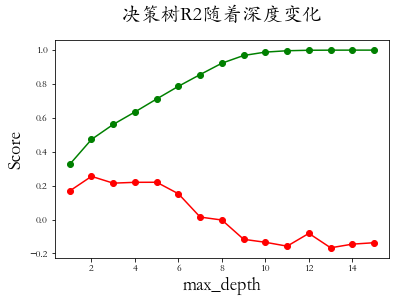

In [55]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'STKaiti'
max_depth = np.arange(1,16)
score1 = [] # 测试
score2 = [] # 训练
for d in max_depth:
    model = DecisionTreeRegressor(max_depth = d)
    model.fit(X_train,y_train)
    score1.append(model.score(X_test,y_test))
    score2.append(model.score(X_train,y_train))
    
plt.plot(max_depth,score1,'ro-')
plt.plot(max_depth,score2,'go-')
plt.xlabel('max_depth',fontsize = 18)
plt.ylabel('Score',fontsize = 18)
plt.title('决策树R2随着深度变化',pad = 20,fontsize = 20)